In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel("C:\\Users\\merom\\Desktop\\Ai&Datascience\\Customer Lifetime Value\\Online Retail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


## Data Preprocessing and Cleaning

In [6]:
# Remove missing descriptions and customer IDs
df = df.dropna(subset=["Description", "CustomerID"])

# Reomve called invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove returns/invalid quantities
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]


In [7]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [8]:
# Change InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].dtype)

datetime64[ns]


## Feature Engineering (The "Past" Window)

In [9]:
## RFM Analysis

# Recency: How recently a customer has made a purchase
# Frequency: How often a customer makes a purchase
# Monetary Value: How much money a customer spends on purchases

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'MonetaryValue']

In [11]:
rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [12]:
# Analytic report


# Customer 12347 appears to be the most valuable customer among the sample because they purchased recently (Recency = 2), 
# made multiple purchases (Frequency = 7), and generated substantial revenue. 

# In contrast, Customer 12346 generated the highest historical revenue but only made a single purchase and has been inactive for 326 days, 
# suggesting a high-value customer who may have churned. 

# Customers 12348 and 12349 show future potential, 
# while Customer 12350 exhibits characteristics of a lost customer due to low spending, low purchase frequency, and long inactivity.

In [13]:
## AOV = Total Revenue / Total Orders

customer_metrics = df.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
)

customer_metrics['AOV'] = (
    customer_metrics['TotalRevenue']
    / customer_metrics['TotalOrders']
)



In [14]:
## Customer Tenure : How long the customer has been with the business.
# Tenure = Last Purchase Date - First Purchase Date

tenure = df.groupby('CustomerID').agg(
    FirstPurchaseDate=('InvoiceDate', 'min'),
    LastPurchaseDate=('InvoiceDate', 'max')
)

tenure['TenureDays'] = (
    tenure['LastPurchaseDate']
    - tenure['FirstPurchaseDate']
).dt.days

##Longer tenure often indicates stronger customer relationships.

In [15]:
## Purchase Gap : Average number of days between purchases.
def avg_purchase_gap(group):
    dates = sorted(group['InvoiceDate'].dt.date.unique())
    if len(dates) < 2:
        return None
    
    gaps = [
        (dates[i] - dates[i-1]).days
        
        for i in range(1, len(dates))
        
        ]
    return sum(gaps) / len(gaps)

In [16]:
purchase_gap = (
    df.groupby('CustomerID')
      .apply(avg_purchase_gap)
      .rename('AvgPurchaseGap')
)

C:\Users\merom\AppData\Local\Temp\ipykernel_30316\1101863591.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(avg_purchase_gap)


In [17]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

customer_features = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate',
             lambda x: (snapshot_date - x.max()).days),

    Frequency=('InvoiceNo', 'nunique'),

    MonetaryValue=('Revenue', 'sum'),

    FirstPurchase=('InvoiceDate', 'min'),

    LastPurchase=('InvoiceDate', 'max')
)

customer_features['AOV'] = (
    customer_features['MonetaryValue']
    / customer_features['Frequency']
)

customer_features['TenureDays'] = (
    customer_features['LastPurchase']
    - customer_features['FirstPurchase']
).dt.days

In [18]:
customer_features = customer_features.join(purchase_gap)

In [19]:
customer_features.head()

,Recency,Frequency,MonetaryValue,FirstPurchase,LastPurchase,AOV,TenureDays,AvgPurchaseGap
CustomerID,,,,,,,,
12346.0,326,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0,NaN
12347.0,2,7,4310.00,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286,365,60.833333
12348.0,75,4,1797.24,2010-12-16 19:09:00,2011-09-25 13:13:00,449.310000,282,94.333333
12349.0,19,1,1757.55,2011-11-21 09:51:00,2011-11-21 09:51:00,1757.550000,0,NaN
12350.0,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0,NaN


In [20]:
## Target Variable: Customer Lifetime Value (CLV)
past_end = '2011-06-30'

past_df = df[df['InvoiceDate'] <= past_end]
future_df = df[df['InvoiceDate'] > past_end]

In [21]:
snapshot_date = past_df['InvoiceDate'].max() + pd.Timedelta(days=1)


## This is my X values, I will use these features to predict the CLV in the future_df
customer_features = past_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    MonetaryValue=('Revenue', 'sum'),
    FirstPurchase=('InvoiceDate', 'min'),
    LastPurchase=('InvoiceDate', 'max')
)

customer_features['AOV'] = (
    customer_features['MonetaryValue']
    / customer_features['Frequency']
)
customer_features['TenureDays'] = (
    customer_features['LastPurchase'] - customer_features['FirstPurchase']
).dt.days

In [22]:
future_clv = future_df.groupby('CustomerID').agg(
    FutureCLV=('Revenue', 'sum')
    )

In [23]:
future_clv

,FutureCLV
CustomerID,
12347.0,2104.05
12348.0,310.00
12349.0,1757.55
12352.0,944.23
12356.0,58.35
...,...
18277.0,110.38
18278.0,173.90
18282.0,178.05


In [24]:
model_df = customer_features.merge(future_clv, on ='CustomerID', how='left')

In [25]:
model_df['FutureCLV'] = (
    model_df['FutureCLV']
    .fillna(0)
)

In [26]:
model_df[['FutureCLV']].describe()

,FutureCLV
count,2954.000000
mean,1345.974039
std,6615.349487
min,0.000000
25%,0.000000
50%,355.680000
75%,1088.817500
max,168469.600000


In [27]:
(model_df['FutureCLV'] == 0).sum()

np.int64(966)

In [28]:
model_df.head()

,Recency,Frequency,MonetaryValue,FirstPurchase,LastPurchase,AOV,TenureDays,FutureCLV
CustomerID,,,,,,,,
12346.0,163,1,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,0,0.00
12347.0,21,4,2205.95,2010-12-07 14:57:00,2011-06-09 13:01:00,551.487500,183,2104.05
12348.0,86,3,1487.24,2010-12-16 19:09:00,2011-04-05 10:47:00,495.746667,109,310.00
12350.0,148,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,334.400000,0,0.00
12352.0,100,5,1561.81,2011-02-16 12:33:00,2011-03-22 16:08:00,312.362000,34,944.23


<Axes: >

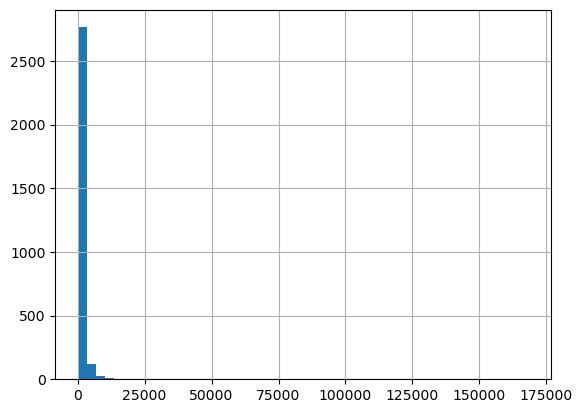

In [29]:
model_df['FutureCLV'].hist(bins=50)

In [30]:
(model_df['FutureCLV'] > 0).mean() * 100

np.float64(67.29857819905213)

##Customer Retention Insight

Analysis of the future observation window revealed that approximately 67.3% of customers returned to make additional purchases, while 32.7% generated no future revenue. This indicates a relatively strong customer retention rate, suggesting that a majority of customers continued engaging with the retailer after their initial purchase history captured in the past window.

In [32]:
model_df['FutureCLV_Log'] = np.log1p(model_df['FutureCLV'])

In [43]:
x = model_df.drop(columns=['FutureCLV', 'FutureCLV_Log'])
y = model_df['FutureCLV_Log']
x = x.drop(columns=['FirstPurchase', 'LastPurchase'])

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2, random_state=42)

In [45]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

lr_preds = lr.predict(x_test)


In [46]:
from sklearn.metrics import mean_absolute_error , r2_score

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression")
print(f"MAE: {lr_mae}")
print(f"R2: {lr_r2}")

Linear Regression
MAE: 2.5702130915524557
R2: 0.1906089313435746


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42,n_jobs=-1)

rf.fit(x_train, y_train)

rf_preds = rf.predict(x_test)

In [49]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor")
print(f"MAE: {rf_mae}")
print(f"R2: {rf_r2}")

Random Forest Regressor
MAE: 2.435542685360181
R2: 0.1621272172378082


In [50]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'R2': [lr_r2, rf_r2]
})
results

,Model,MAE,R2
0,Linear Regression,2.570213,0.190609
1,Random Forest,2.435543,0.162127


In [51]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

         Feature  Importance
2  MonetaryValue    0.453083
0        Recency    0.242237
3            AOV    0.194278
4     TenureDays    0.078441
1      Frequency    0.031961


In [ ]:
##Feature importance analysis from the Random Forest model revealed that Monetary Value was the strongest predictor of future customer 
# value (45.3%),
# suggesting that the amount customers spend is more important than the number of purchases they make when forecasting future revenue.
# followed by Recency (24.2%) and Average Order Value (19.4%). 
# Surprisingly, purchase Frequency contributed relatively little predictive power (3.2%), 

In [ ]:
##Two regression models were evaluated for predicting future customer value. 
# Linear Regression achieved an R² score of 0.19, slightly outperforming the Random Forest model (R² = 0.16), 
# while Random Forest achieved a marginally lower MAE.
# Feature importance analysis identified Monetary Value, Recency, and Average Order Value as the strongest predictors of future spending. 
# The results suggest that historical spending behavior provides useful signals for forecasting customer value,
# though additional behavioral features could further improve predictive performance.

In [53]:
pred_log = rf.predict(x)
model_df['PredictedCLV'] = np.expm1(pred_log)

In [54]:
model_df['CLV_Segment'] = pd.qcut(
    model_df['PredictedCLV'],
    q=4,
    labels=['Low', 'Mid', 'High', 'VIP']
)

In [55]:
model_df['CLV_Segment'].value_counts()

CLV_Segment
Low     739
VIP     739
Mid     738
High    738
Name: count, dtype: int64

In [56]:
segment_summary = model_df.groupby('CLV_Segment').agg({
    'PredictedCLV':'mean',
    'MonetaryValue':'mean',
    'Frequency':'mean',
    'Recency':'mean'
})

segment_summary

C:\Users\merom\AppData\Local\Temp\ipykernel_30316\52622994.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = model_df.groupby('CLV_Segment').agg({


,PredictedCLV,MonetaryValue,Frequency,Recency
CLV_Segment,,,,
Low,2.447879,576.215372,1.397835,103.041949
Mid,58.243857,465.613917,1.658537,86.794038
High,308.776458,687.364539,2.176152,64.173442
VIP,3028.601878,3620.218336,6.595399,33.916103


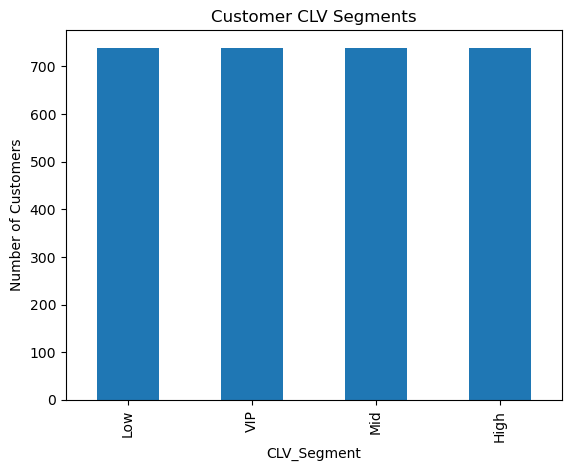

In [57]:
import matplotlib.pyplot as plt

model_df['CLV_Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer CLV Segments')
plt.ylabel('Number of Customers')
plt.show()

In [58]:
strategy_df = pd.DataFrame({
    'Segment': ['VIP', 'High', 'Mid', 'Low'],
    'Business Goal': [
        'Retention',
        'Upsell',
        'Engagement',
        'Reactivation'
    ],
    'Recommended Action': [
        'VIP Rewards Program',
        'Cross-Selling Campaigns',
        'Personalized Promotions',
        'Discount/Re-engagement Offers'
    ]
})

strategy_df

,Segment,Business Goal,Recommended Action
0,VIP,Retention,VIP Rewards Program
1,High,Upsell,Cross-Selling Campaigns
2,Mid,Engagement,Personalized Promotions
3,Low,Reactivation,Discount/Re-engagement Offers
